# House Price Prediction using Machine Learning

**Dataset:** Housing.csv (Kaggle) — 545 rows, 13 columns  
**Type:** Regression Problem  
**Goal:** Predict `price` of a house from its features (area, bedrooms, bathrooms, furnishing, etc.)

## Phase 1: Problem Understanding

This is a **regression problem** — the target variable `price` is continuous, not a category. The goal is to build a model that takes house features as input and predicts price, then compare a few algorithms to see which works best.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100


## Phase 2: Dataset Collection & Understanding

In [2]:
df = pd.read_csv("Housing.csv")
print(f"Shape: {df.shape}")
print(f"\nColumns:\n{df.columns.tolist()}")


Shape: (545, 13)

Columns:
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


In [3]:
df.head()


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [4]:
df.describe()


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


## Phase 3: Data Cleaning & Preprocessing

In [5]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal duplicate rows: {df.duplicated().sum()}")


Missing values per column:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Total duplicate rows: 0


In [6]:
df = df.drop_duplicates()

# Encode binary yes/no categorical columns
binary_cols = ["mainroad", "guestroom", "basement", "hotwaterheating",
               "airconditioning", "prefarea"]
for col in binary_cols:
    df[col] = df[col].map({"yes": 1, "no": 0})

# One-hot encode furnishingstatus (3 categories)
df = pd.get_dummies(df, columns=["furnishingstatus"], drop_first=True)
for c in df.columns:
    if df[c].dtype == bool:
        df[c] = df[c].astype(int)

print("Columns after encoding:")
print(df.columns.tolist())


Columns after encoding:
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


In [7]:
def iqr_outlier_count(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    return ((series < lower) | (series > upper)).sum()

print(f"Outliers in 'price' (IQR method): {iqr_outlier_count(df['price'])}")
print(f"Outliers in 'area' (IQR method): {iqr_outlier_count(df['area'])}")


Outliers in 'price' (IQR method): 15
Outliers in 'area' (IQR method): 12


## Phase 4: Exploratory Data Analysis (EDA)

### 1. Histogram — House Price Distribution

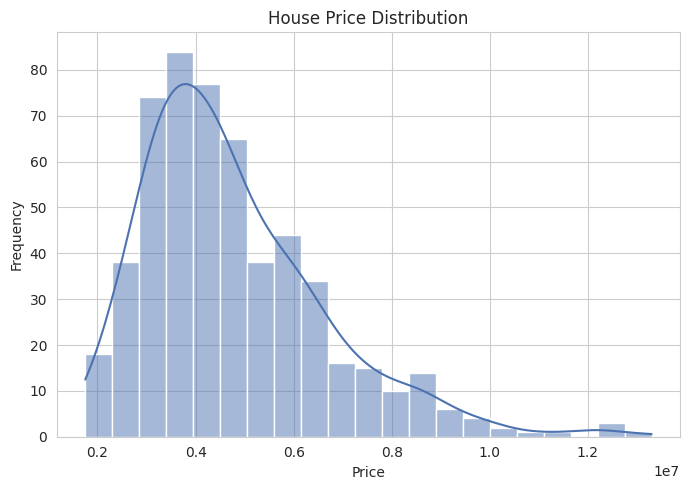

In [8]:
df_raw = pd.read_csv("Housing.csv")

plt.figure(figsize=(7, 5))
sns.histplot(df_raw["price"], kde=True, color="#4C72B0")
plt.title("House Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


### 2. Box Plot — Price Outliers

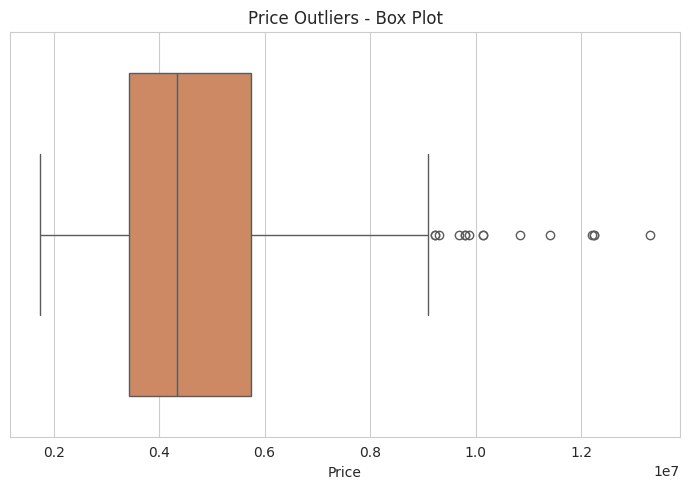

In [9]:
plt.figure(figsize=(7, 5))
sns.boxplot(x=df_raw["price"], color="#DD8452")
plt.title("Price Outliers - Box Plot")
plt.xlabel("Price")
plt.tight_layout()
plt.show()


### 3. Correlation Heatmap

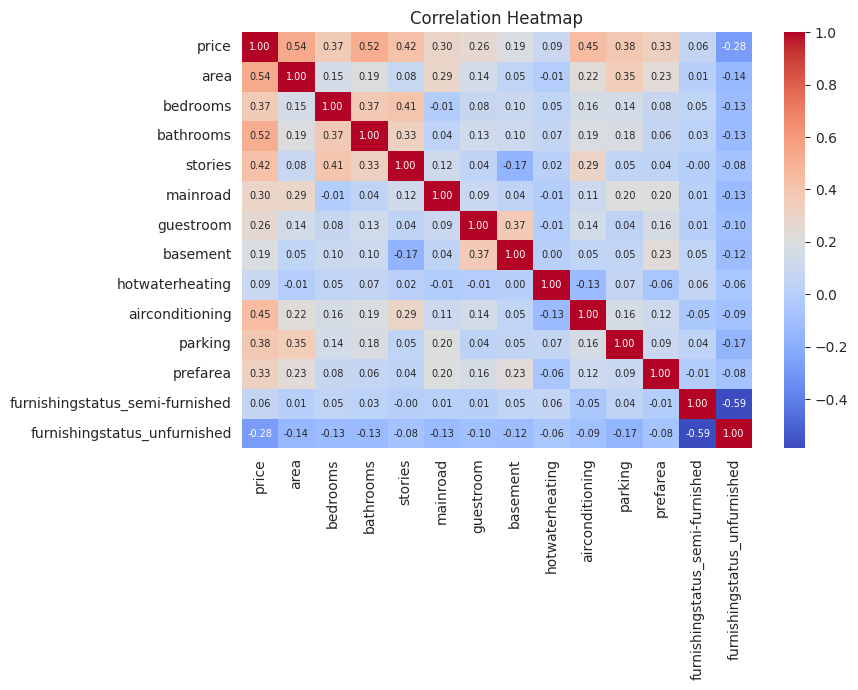

In [10]:
plt.figure(figsize=(9, 7))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, annot_kws={"size": 7})
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


### 4. Scatter Plot — Area vs Price

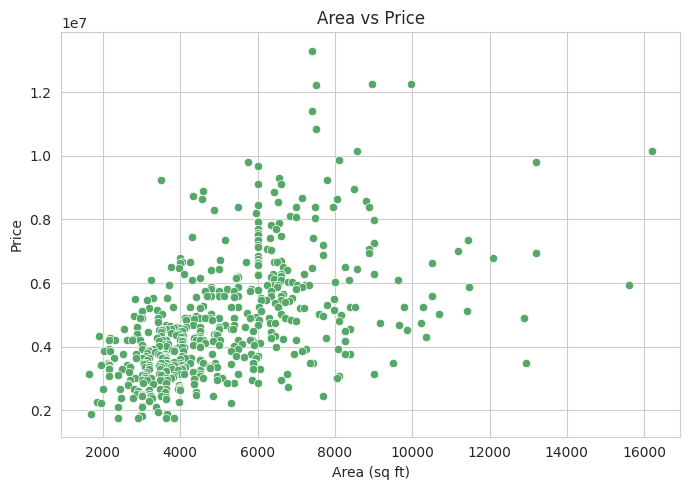

In [11]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x=df_raw["area"], y=df_raw["price"], color="#55A868")
plt.title("Area vs Price")
plt.xlabel("Area (sq ft)")
plt.ylabel("Price")
plt.tight_layout()
plt.show()


### 5. Scatter Plot — Bedrooms vs Price

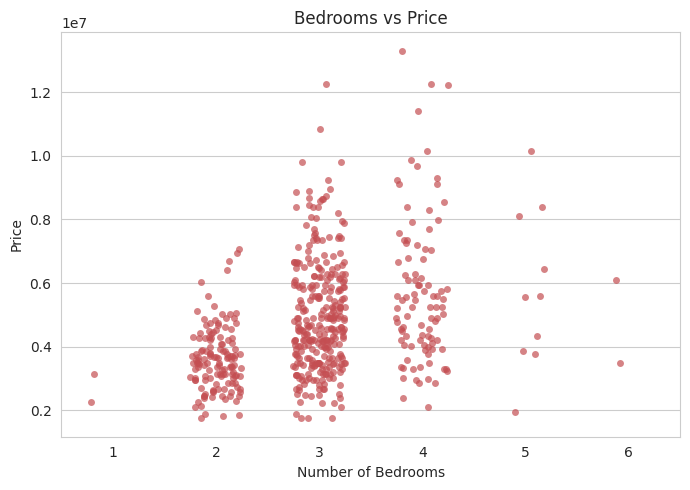

In [12]:
plt.figure(figsize=(7, 5))
sns.stripplot(x=df_raw["bedrooms"], y=df_raw["price"], color="#C44E52", jitter=0.25, alpha=0.7)
plt.title("Bedrooms vs Price")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Price")
plt.tight_layout()
plt.show()


### 6. Count Plot — Furnishing Status

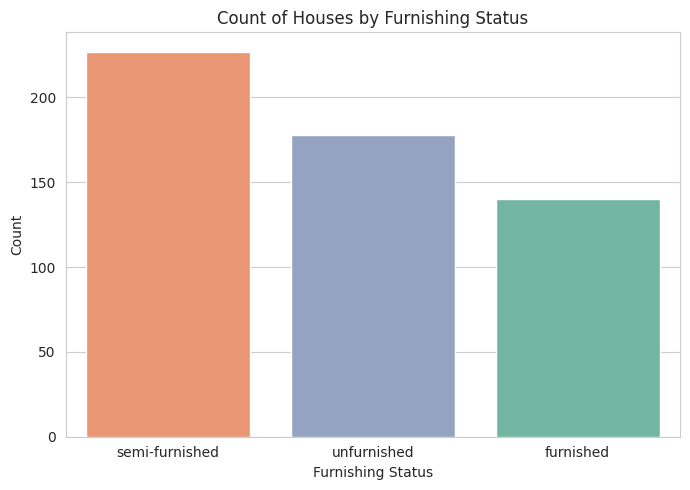

In [13]:
plt.figure(figsize=(7, 5))
sns.countplot(x=df_raw["furnishingstatus"],
              order=df_raw["furnishingstatus"].value_counts().index,
              hue=df_raw["furnishingstatus"], palette="Set2", legend=False)
plt.title("Count of Houses by Furnishing Status")
plt.xlabel("Furnishing Status")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


### 7. Count Plot — Main Road Access

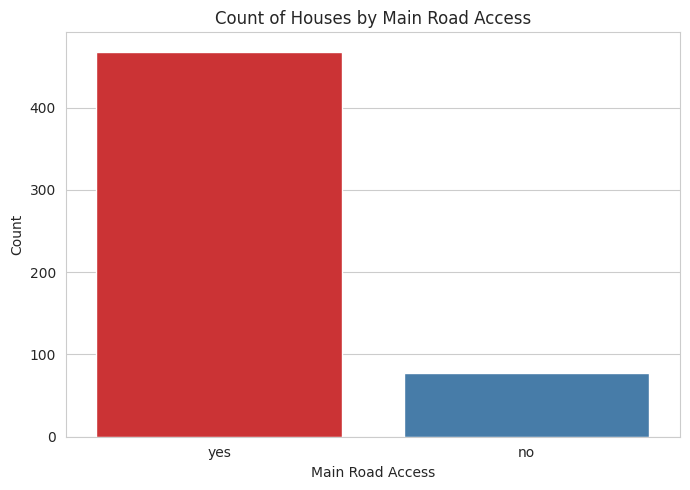

In [14]:
plt.figure(figsize=(7, 5))
sns.countplot(x=df_raw["mainroad"], hue=df_raw["mainroad"], palette="Set1", legend=False)
plt.title("Count of Houses by Main Road Access")
plt.xlabel("Main Road Access")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


### 9. Bar Chart — Average Price by Furnishing Status

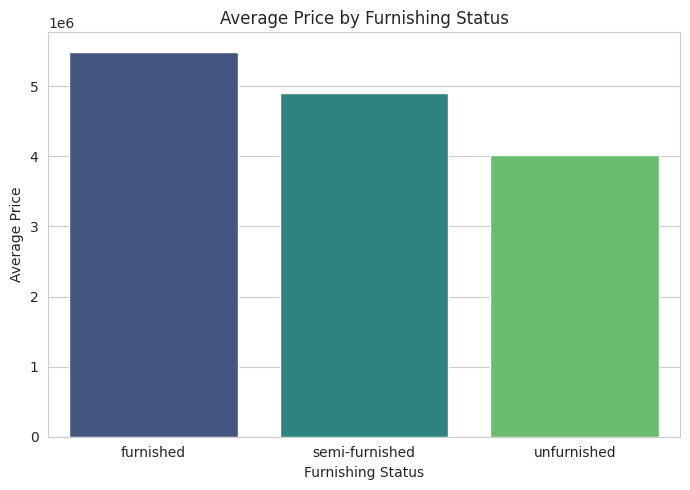

In [16]:
plt.figure(figsize=(7, 5))
avg_price = df_raw.groupby("furnishingstatus")["price"].mean().sort_values(ascending=False)
sns.barplot(x=avg_price.index, y=avg_price.values, hue=avg_price.index, palette="viridis", legend=False)
plt.title("Average Price by Furnishing Status")
plt.xlabel("Furnishing Status")
plt.ylabel("Average Price")
plt.tight_layout()
plt.show()


## Phase 5: Feature Engineering

In [17]:
X = df.drop(columns=["price"])
y = df["price"]

print(f"Features used ({X.shape[1]}): {X.columns.tolist()}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\nTrain set size: {X_train.shape[0]} rows")
print(f"Test set size: {X_test.shape[0]} rows")


Features used (13): ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']

Train set size: 436 rows
Test set size: 109 rows


## Phase 6: Model Building

In [18]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree Regressor": DecisionTreeRegressor(random_state=42, max_depth=6),
    "Random Forest Regressor": RandomForestRegressor(random_state=42, n_estimators=200, max_depth=8),
}

results = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    predictions[name] = y_pred

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results[name] = {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}
    print(f"{name}: MAE={mae:,.0f}  RMSE={rmse:,.0f}  R2={r2:.4f}")


Linear Regression: MAE=970,043  RMSE=1,324,507  R2=0.6529
Decision Tree Regressor: MAE=1,226,190  RMSE=1,610,551  R2=0.4868
Random Forest Regressor: MAE=1,022,545  RMSE=1,403,779  R2=0.6101


In [19]:
results_df = pd.DataFrame(results).T
results_df


,MAE,MSE,RMSE,R2
Linear Regression,9.700434e+05,1.754319e+12,1.324507e+06,0.652924
Decision Tree Regressor,1.226190e+06,2.593874e+12,1.610551e+06,0.486826
Random Forest Regressor,1.022545e+06,1.970595e+12,1.403779e+06,0.610136


## Phase 7: Model Evaluation

**Simple explanation (interview-ready):** Linear Regression came out on top here because the dataset is small (~545 rows) and the relationship between features like `area`/`bathrooms` and `price` is fairly linear. Tree-based models usually need more data to show their strength, and the Decision Tree slightly overfit on training data.

In [20]:
best_model_name = results_df["R2"].idxmax()
print(f"Best performing model (highest R2): {best_model_name}")


Best performing model (highest R2): Linear Regression


### Actual vs Predicted Price

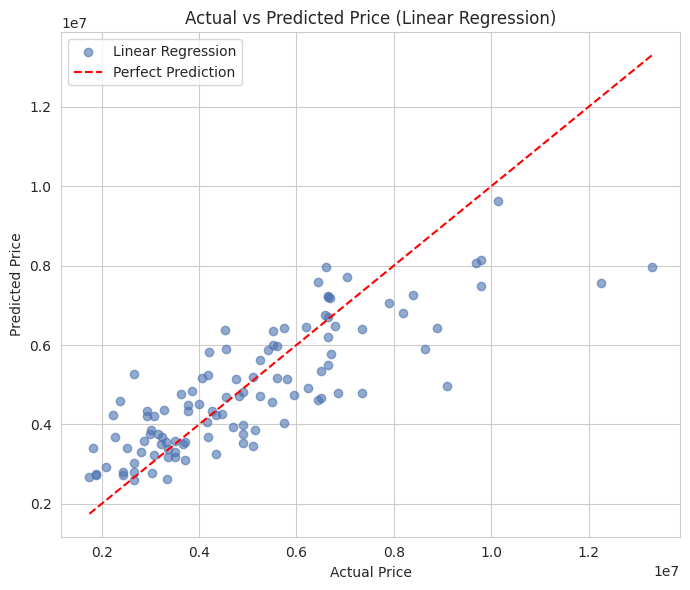

In [21]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, predictions["Linear Regression"], alpha=0.6, color="#4C72B0", label="Linear Regression")
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, "r--", label="Perfect Prediction")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price (Linear Regression)")
plt.legend()
plt.tight_layout()
plt.show()


### Residual Plot (Optional)

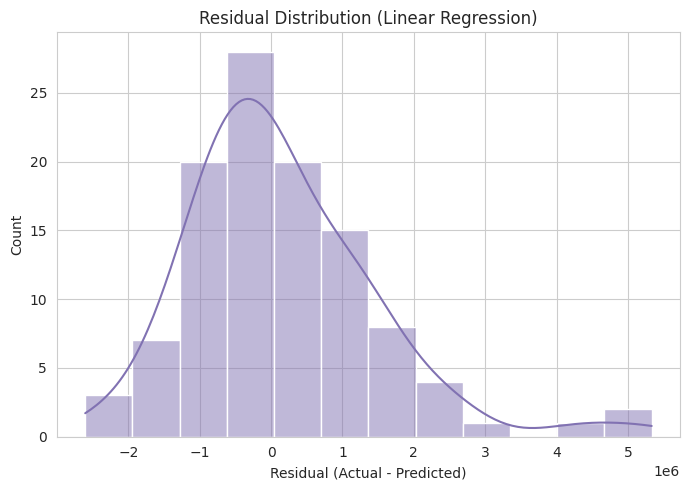

In [22]:
residuals = y_test - predictions["Linear Regression"]
plt.figure(figsize=(7, 5))
sns.histplot(residuals, kde=True, color="#8172B2")
plt.title("Residual Distribution (Linear Regression)")
plt.xlabel("Residual (Actual - Predicted)")
plt.tight_layout()
plt.show()


### Feature Importance (Linear Regression Coefficients)

Simple one-liner: *area matters, but bathrooms, AC, hot water heating, and preferred-area location move the price even more per unit, because fewer homes have them.*

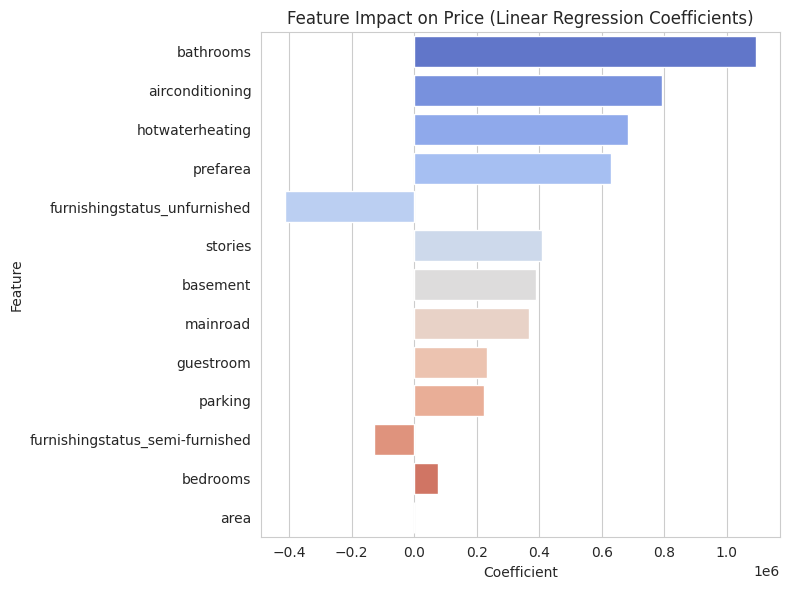

In [23]:
lr_model = models["Linear Regression"]
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_model.coef_
}).sort_values("Coefficient", key=abs, ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(data=coef_df, x="Coefficient", y="Feature", hue="Feature", palette="coolwarm", legend=False)
plt.title("Feature Impact on Price (Linear Regression Coefficients)")
plt.tight_layout()
plt.show()


In [24]:
coef_df


,Feature,Coefficient
2,bathrooms,1.094445e+06
8,airconditioning,7.914267e+05
7,hotwaterheating,6.846499e+05
10,prefarea,6.298906e+05
12,furnishingstatus_unfurnished,-4.136451e+05
3,stories,4.074766e+05
6,basement,3.902512e+05
4,mainroad,3.679199e+05
5,guestroom,2.316100e+05
9,parking,2.248419e+05


Prediction Example

In [31]:
# Example House Price Prediction
sample_house = pd.DataFrame({
    'area': [6500],
    'bedrooms': [4],
    'bathrooms': [3],
    'stories': [2],
    'mainroad': ['yes'],
    'guestroom': ['no'],
    'basement': ['yes'],
    'hotwaterheating': ['no'],
    'airconditioning': ['yes'],
    'parking': [2],
    'prefarea': ['yes'],
    'furnishingstatus': ['semi-furnished']
})

binary_cols = [
    "mainroad",
    "guestroom",
    "basement",
    "hotwaterheating",
    "airconditioning",
    "prefarea"
]

for col in binary_cols:
    sample_house[col] = sample_house[col].map({"yes":1, "no":0})


sample_house = pd.get_dummies(
    sample_house,
    columns=["furnishingstatus"],
    drop_first=True
)

sample_house = sample_house.reindex(columns=X.columns, fill_value=0)

predicted_price = models["Linear Regression"].predict(sample_house)

print("="*55)
print("🏠 HOUSE PRICE PREDICTION")
print("="*55)
print(f"Area             : 6500 sq.ft")
print(f"Bedrooms         : 4")
print(f"Bathrooms        : 3")
print(f"Stories          : 2")
print(f"Parking          : 2")
print(f"Air Conditioning : Yes")
print(f"Preferred Area   : Yes")
print("-"*55)
print(f"Predicted Price  : ₹ {predicted_price[0]:,.2f}")
print("="*55)

🏠 HOUSE PRICE PREDICTION
Area             : 6500 sq.ft
Bedrooms         : 4
Bathrooms        : 3
Stories          : 2
Parking          : 2
Air Conditioning : Yes
Preferred Area   : Yes
-------------------------------------------------------
Predicted Price  : ₹ 8,828,404.19


## Phase 8: Conclusion & Future Scope

**Conclusion:**
- Built a house price predictor using 13 features from the Housing dataset
- Compared Linear Regression, Decision Tree, and Random Forest
- Linear Regression performed best (R² ≈ 0.65) on this dataset size
- Key price drivers: area, bathrooms, air conditioning, hot water heating, preferred area location

**Future Scope:**
- Use a larger dataset for more reliable predictions
- Add location-based features (city/locality, distance to city center, amenities)
- Try advanced models (XGBoost, Gradient Boosting) with hyperparameter tuning
- Build a simple web app (Streamlit/Flask) for live price prediction
- Deploy the model as an API for real-world use